In [34]:
import numpy as np
from utils import *
from upload_utils import *
from model_utils import *
from datetime import datetime, timedelta
import pandas as pd
import time
import os, pickle, json
from datetime import datetime

In [35]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from datetime import datetime, timedelta
import geopandas as gpd


In [36]:
geo_data = gpd.read_file('./data_imdc_2026/shape_muni.gpkg')
geo_data.head()

,geocode,geocode_name,uf,uf_code,geometry
0,1100015,Alta Floresta D'oeste,RO,11,"MULTIPOLYGON (((-61.96836 -12.13407, -61.96827..."
1,1100023,Ariquemes,RO,11,"MULTIPOLYGON (((-63.18282 -10.13892, -63.18615..."
2,1100031,Cabixi,RO,11,"MULTIPOLYGON (((-60.70518 -13.32474, -60.70904..."
3,1100049,Cacoal,RO,11,"MULTIPOLYGON (((-61.3474 -11.50562, -61.34569 ..."
4,1100056,Cerejeiras,RO,11,"MULTIPOLYGON (((-60.82417 -13.11156, -60.82289..."


In [37]:
# State administrative mapping for competition submission
adm_1_map = {
    'Acre': 'AC', 'Alagoas': 'AL', 'Amapá': 'AP', 'Amazonas': 'AM', 'Bahia': 'BA', 'Ceará': 'CE',
    'Distrito Federal': 'DF', 'Goiás': 'GO', 'Maranhão': 'MA', 'Mato Grosso': 'MT',
    'Mato Grosso do Sul': 'MS', 'Minas Gerais': 'MG', 'Pará': 'PA', 'Paraíba': 'PB',
    'Paraná': 'PR', 'Pernambuco': 'PE', 'Piauí': 'PI', 'Rio de Janeiro': 'RJ', 'Rio Grande do Norte': 'RN',
    'Rio Grande do Sul': 'RS', 'Rondônia': 'RO', 'Roraima': 'RR', 'Santa Catarina': 'SC',
    'São Paulo': 'SP', 'Sergipe': 'SE', 'Tocantins': 'TO'
}

# Complete list of Brazilian states for analysis ()
brazilian_states = [
    'Acre', 'Alagoas', 'Amapá', 'Amazonas', 'Bahia', 'Ceará',
    'Distrito Federal', 'Goiás', 'Maranhão', 'Mato Grosso',
    'Mato Grosso do Sul', 'Minas Gerais', 'Pará', 'Paraíba',
    'Paraná', 'Pernambuco', 'Piauí', 'Rio de Janeiro', 'Rio Grande do Norte',
    'Rio Grande do Sul', 'Rondônia', 'Roraima', 'Santa Catarina',
    'São Paulo', 'Sergipe', 'Tocantins'
]

In [38]:
"""for state in brazilian_states:

    print(state)
    state = adm_1_map[state]
    print(state)

    state_geocodes = geo_data[geo_data.uf == state]['geocode']
    
    _, major_cities = fetch_dengue_data_state_from_csv(state_geocodes, "2021-10-11", "2024-06-30")
    print(major_cities)
    major_cities_dir = f"./data_imdc_2026/major_cities/{state}"
    os.makedirs(major_cities_dir, exist_ok=True)
    major_cities_cache_file = os.path.join(major_cities_dir, "major.pickle")

    with open(major_cities_cache_file, 'wb') as f:
        major_cities = pickle.dump(major_cities, f)""";


In [39]:
all_major = []
for state in brazilian_states:

    state = adm_1_map[state]
    print(state)
    major_cities_dir = f"./data_imdc_2026/major_cities/{state}"
    os.makedirs(major_cities_dir, exist_ok=True)
    major_cities_cache_file = os.path.join(major_cities_dir, "major.pickle")

    with open(major_cities_cache_file, 'rb') as f:
        major_cities = pickle.load(f)

    for city in major_cities:
        all_major.append(city)

all_major = set(all_major)

AC
AL
AP
AM
BA
CE
DF
GO
MA
MT
MS
MG
PA
PB
PR
PE
PI
RJ
RN
RS
RO
RR
SC
SP
SE
TO


In [40]:
weather_data = pd.read_csv('./data_imdc_2026/climate.csv', parse_dates=['date']).sort_values('date')


In [41]:
weather_data.head()

,date,epiweek,geocode,temp_min,temp_med,temp_max,precip_min,precip_med,precip_max,pressure_min,pressure_med,pressure_max,rel_humid_min,rel_humid_med,rel_humid_max,thermal_range,rainy_days
0,1999-12-26,199952,2700102,20.2255,25.6117,31.6680,0.0000,0.0218,0.1679,0.9531,0.9552,0.9566,37.9548,67.1799,93.8398,11.4425,1
1653752,1999-12-26,199952,2606200,23.8888,26.1844,28.9935,0.0117,0.8538,1.4891,0.9884,0.9900,0.9911,66.4830,79.4924,91.1047,5.1047,1
5967471,1999-12-26,199952,5006903,23.8330,26.9228,30.3703,0.1419,1.7380,9.9422,0.9683,0.9712,0.9727,51.6269,73.1020,86.9605,6.5373,1
2090463,1999-12-26,199952,2210391,21.5765,25.3109,29.9394,3.6588,4.7520,5.5255,0.9640,0.9670,0.9687,58.5170,81.1061,97.2761,8.3629,1
5530760,1999-12-26,199952,5212105,20.7826,22.3614,24.3518,0.0147,4.2812,10.7404,0.9166,0.9191,0.9204,77.5617,86.4064,93.4495,3.5692,1


<Axes: xlabel='date'>

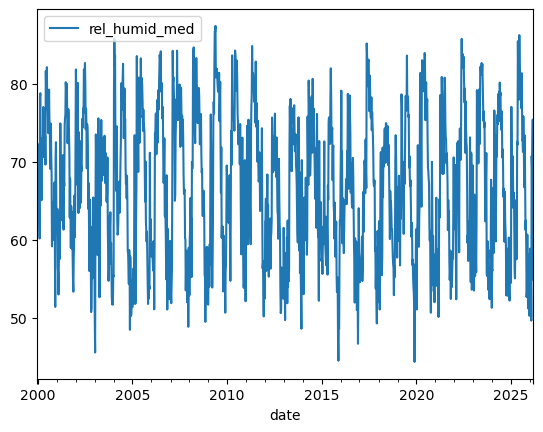

In [42]:
weather_data[weather_data.geocode == 2700102].plot(x='date',y='rel_humid_med')

In [43]:
weather_data = weather_data[['date','epiweek','geocode','temp_med','precip_med','pressure_med','rel_humid_med']]

In [44]:
weather_data = weather_data[weather_data.geocode.isin(all_major)]

In [45]:
weather_data = weather_data[weather_data['date'].dt.year >= 2010]


In [46]:
weather_data.head()

,date,epiweek,geocode,temp_med,precip_med,pressure_med,rel_humid_med
5153439,2010-01-03,201001,1200807,26.694314,11.5109,0.976029,83.086686
2133425,2010-01-03,201001,2801108,26.624443,6.4857,0.985500,73.600829
7554665,2010-01-03,201001,4125555,27.163900,10.9814,0.956171,78.454071
5156177,2010-01-03,201001,1500131,25.892443,15.9220,0.973286,80.231229
4504533,2010-01-03,201001,3300159,27.431900,3.3552,0.980857,77.090943


In [47]:
# 1. set index on dates 
weather_data = weather_data.set_index('date')

In [48]:

# Step 1: Resample and interpolate linearly
weather_data_daily = (
    weather_data
    .groupby('geocode')
    .resample('D')
    .mean()
    .drop(columns='geocode', errors='ignore')
    .reset_index()
)

# Step 2: Interpolate remaining NaN values per geocode
numeric_cols = ['temp_med', 'rel_humid_med', 'precip_med', 'pressure_med']  # adjust as needed

for geocode in weather_data_daily['geocode'].unique():
    mask = weather_data_daily['geocode'] == geocode
    for col in numeric_cols:
        # Linear interpolation for any remaining NaN
        weather_data_daily.loc[mask, col] = (
            weather_data_daily.loc[mask, col]
            .interpolate(method='linear', limit_direction='both')
        )
        
        # Fill any remaining NaN at edges with nearest value
        weather_data_daily.loc[mask, col] = (
            weather_data_daily.loc[mask, col]
            .fillna(method='ffill')
            .fillna(method='bfill')
        )

# Step 3: Apply smoothing to remove roughness
for col in numeric_cols:
    weather_data_daily[col] = (
        weather_data_daily
        .groupby('geocode')[col]
        .transform(lambda x: x.rolling(7, center=True, min_periods=1).mean())
    )

In [49]:
weather_data_daily.head()

,geocode,date,epiweek,temp_med,precip_med,pressure_med,rel_humid_med
0,1100031,2010-01-03,201001.0,25.533555,34.377736,0.967722,87.386086
1,1100031,2010-01-04,NaN,25.445945,36.447614,0.967863,87.717371
2,1100031,2010-01-05,NaN,25.358335,38.517493,0.968004,88.048657
3,1100031,2010-01-06,NaN,25.270724,40.587371,0.968145,88.379943
4,1100031,2010-01-07,NaN,25.095504,44.727129,0.968427,89.042514


In [50]:
# interpolated using the mean, but precipitations are additive quantities
weather_data_daily['precip_med'] = weather_data_daily['precip_med']/7

In [24]:
#weather_data_daily['dwpt'] = weather_data_daily[['temp_med','rel_humid_med']].apply(lambda x: comp_dew_point(x[0],x[1]), axis=1)

In [25]:
#weather_data_daily['evap'] = weather_data_daily[['temp_med','rel_humid_med','pressure_med','precip_med']].apply(lambda x: comp_evaporation(x[0],x[1],x[2],x[3]), axis=1)


In [51]:
weather_data_daily.to_parquet('./data_imdc_2026/weather_data_daily.parquet', engine='fastparquet')

In [52]:
weather_data_daily.head()

,geocode,date,epiweek,temp_med,precip_med,pressure_med,rel_humid_med
0,1100031,2010-01-03,201001.0,25.533555,4.911105,0.967722,87.386086
1,1100031,2010-01-04,NaN,25.445945,5.206802,0.967863,87.717371
2,1100031,2010-01-05,NaN,25.358335,5.502499,0.968004,88.048657
3,1100031,2010-01-06,NaN,25.270724,5.798196,0.968145,88.379943
4,1100031,2010-01-07,NaN,25.095504,6.389590,0.968427,89.042514


<Axes: xlabel='date'>

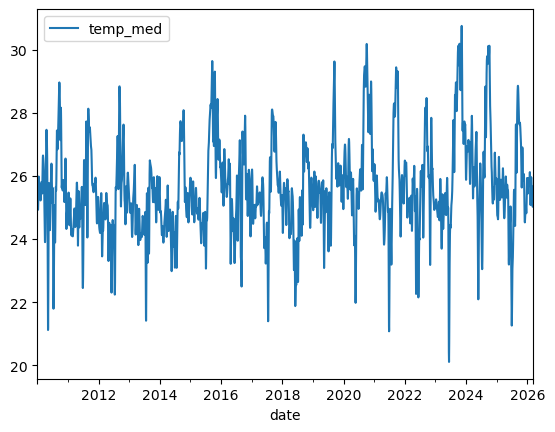

In [53]:
weather_data_daily[weather_data_daily.geocode==1100031].plot(x='date',y='temp_med')

<Axes: xlabel='date'>

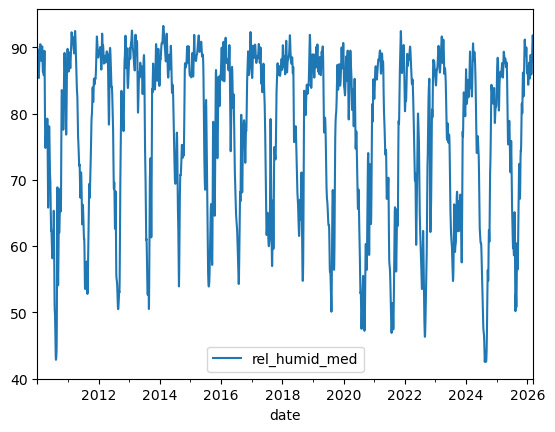

In [54]:
weather_data_daily[weather_data_daily.geocode==1100031].plot(x='date',y='rel_humid_med')